# 01 — Training GALERIA (satu notebook lengkap)

Setup -> data -> **hyperparameter tuning (opsional)** -> model -> **training** ->
visualisasi (gradient descent, learning curve, LR schedule) -> **evaluasi**
(metrik, confusion matrix, contoh prediksi).

Logic berat diimpor dari `ml/src/` (satu sumber, dipakai juga oleh
`python -m src.train`). Notebook ini merangkai + menampilkan semua inline.
**Semua tahap — setup, tuning, training, evaluasi — ada di notebook ini, tidak
dipecah ke file lain.**

> **Kernel wajib ada `torch`.** Kalau `ModuleNotFoundError: torch`, ganti kernel
> ke Python yang ada torch-nya.

Prasyarat: `python -m src.preprocess` sudah dijalankan (`data/processed/` terisi).

## 1. Setup

In [1]:
%matplotlib inline
import os, sys
from pathlib import Path

# pindah ke folder ml/ supaya `import src` & path config jalan
_p = Path.cwd()
while not ((_p / "src").is_dir() and (_p / "configs").is_dir()):
    if _p == _p.parent:
        raise RuntimeError("folder ml/ (berisi src/ & configs/) tidak ketemu")
    _p = _p.parent
os.chdir(_p)
if str(_p) not in sys.path:
    sys.path.insert(0, str(_p))

import json, math, time, copy
import numpy as np
import pandas as pd
import torch, torch.nn as nn
import matplotlib.pyplot as plt
import torchvision

torch.backends.cudnn.benchmark = True   # ukuran input tetap -> cuDNN pilih kernel tercepat

print("working dir :", os.getcwd())
print("python      :", sys.version.split()[0])
print("torch       :", torch.__version__, "| torchvision", torchvision.__version__)
print("CUDA        :", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

working dir : c:\Users\thori\Downloads\Semester 5\projek galeria\ml
python      : 3.11.8
torch       : 2.14.0+cu130 | torchvision 0.29.0+cu130
CUDA        : True | NVIDIA GeForce RTX 2050


In [2]:
from src.utils import load_config, set_seed, get_device, resolve_path
from src.dataset import build_label_mapping, create_dataloaders
from src.model import build_model, save_checkpoint, load_checkpoint
from src.train import (build_optimizer, build_scheduler, train_one_epoch,
                       validate, make_scaler)
from src.evaluate import run_inference, compute_metrics

cfg = load_config("configs/config.yaml")
cfg["train"]["num_workers"] = 0            # Windows + Jupyter: 0 paling aman
cfg["train"]["early_stopping_patience"] = 6   # val plateau cepat -> patience 10 buang ~10 epoch
# cfg["train"]["epochs"] = 8               # <- uncomment untuk uji cepat

set_seed(cfg["seed"])
device = get_device(cfg["device"])
use_amp = bool(cfg["train"]["mixed_precision"]) and device.type == "cuda"
print("device:", device, "\n")

# variabel BERSAMA (dipakai lintas sel; taruh di sini biar re-run sel individual aman)
MEAN = torch.tensor(cfg["image"]["mean"]).view(3, 1, 1)
STD  = torch.tensor(cfg["image"]["std"]).view(3, 1, 1)

def denorm(t):
    return (t * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

for sec in ["image", "augmentation", "model", "train", "checkpoint", "eval"]:
    print(f"[{sec}]"); print(json.dumps(cfg[sec], indent=2, ensure_ascii=False)); print()

device: cuda 

[image]
{
  "size": 224,
  "resize": 256,
  "mean": [
    0.485,
    0.456,
    0.406
  ],
  "std": [
    0.229,
    0.224,
    0.225
  ],
  "pad_to_square": false,
  "pad_mode": "edge",
  "pad_fill": 255
}

[augmentation]
{
  "horizontal_flip": 0.5,
  "rotation_degrees": 10,
  "color_jitter": {
    "brightness": 0.2,
    "contrast": 0.2,
    "saturation": 0.2,
    "hue": 0.05
  },
  "trivial_augment": true
}

[model]
{
  "name": "convnext_small",
  "pretrained": true,
  "train_mode": "finetune_partial",
  "unfreeze_last_n_blocks": 2,
  "unfreeze_frac": 0.4,
  "dropout": 0.4,
  "embedding_dim": 2048
}

[train]
{
  "epochs": 40,
  "batch_size": 24,
  "num_workers": 0,
  "optimizer": "adamw",
  "learning_rate": 0.0003,
  "backbone_lr_mult": 0.1,
  "weight_decay": 0.0005,
  "scheduler": "cosine",
  "step_size": 10,
  "gamma": 0.1,
  "label_smoothing": 0.1,
  "mixed_precision": true,
  "grad_clip_norm": 1.0,
  "early_stopping_patience": 6,
  "use_weighted_sampler": true
}

[

## 2. Data

11 kelas: ['Art_Nouveau', 'Baroque', 'Cubism', 'Expressionism', 'Impressionism', 'Naive_Art_Primitivism', 'Northern_Renaissance', 'Post_Impressionism', 'Realism', 'Romanticism', 'Symbolism']
                       train  val  test
style_name                             
Impressionism           1162  249   249
Realism                  745  160   160
Post_Impressionism       397   86    85
Romanticism              296   63    64
Symbolism                293   62    63
Art_Nouveau              281   60    60
Northern_Renaissance     178   39    38
Baroque                  164   35    35
Expressionism            160   34    34
Naive_Art_Primitivism    149   32    32
Cubism                    93   20    20


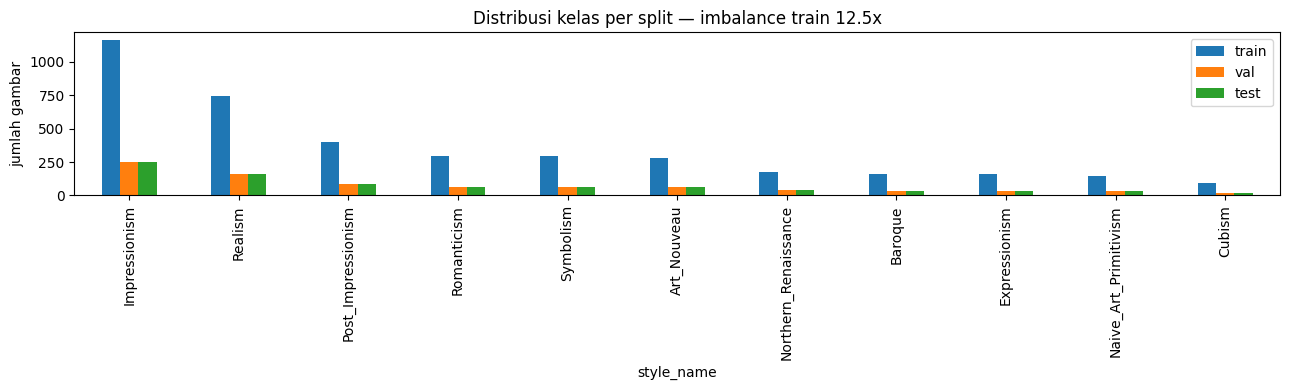

In [3]:
label_to_idx = build_label_mapping(cfg)
idx_to_label = {v: k for k, v in label_to_idx.items()}
num_classes  = len(label_to_idx)
class_names  = [idx_to_label[i] for i in range(num_classes)]   # bersama
print(f"{num_classes} kelas:", class_names)

dist = {}
for name in ("train", "val", "test"):
    d = pd.read_csv(resolve_path(cfg["data"][f"{name}_csv"]))
    dist[name] = d[cfg["data"]["label_column"]].value_counts()
dist = pd.DataFrame(dist).fillna(0).astype(int).sort_values("train", ascending=False)
print(dist)

ax = dist.plot(kind="bar", figsize=(13, 4))
ax.set_title(f"Distribusi kelas per split — imbalance train "
             f"{dist['train'].max()/dist['train'].min():.1f}x")
ax.set_ylabel("jumlah gambar"); plt.tight_layout(); plt.show()

In [4]:
loaders = create_dataloaders(cfg)
print({k: f"{len(v)} batch / {len(v.dataset)} img" for k, v in loaders.items()})

{'train': '163 batch / 3918 img', 'val': '35 batch / 840 img', 'test': '35 batch / 840 img'}


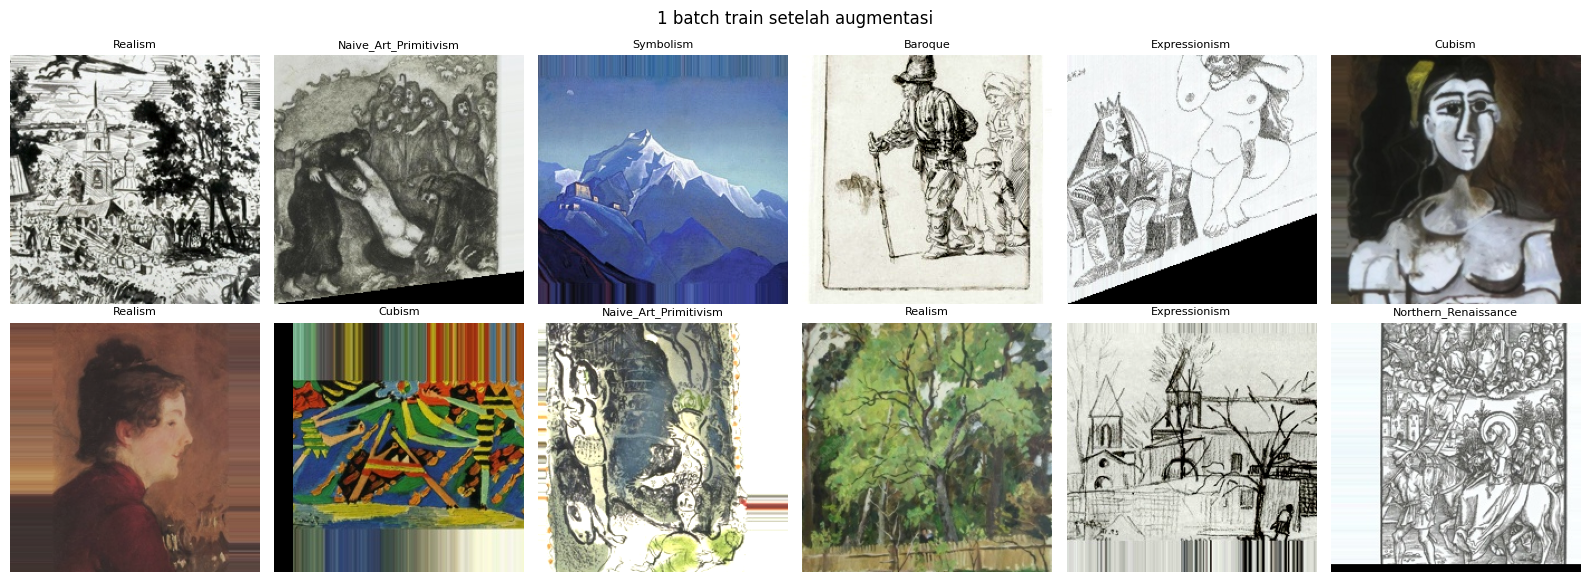

In [5]:
# contoh 1 batch train (SquarePad sudah di-preprocess; ini + augmentasi TrivialAugment)
imgs, labels = next(iter(loaders["train"]))
n = min(12, len(imgs))
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(denorm(imgs[i])); ax.set_title(idx_to_label[labels[i].item()], fontsize=8)
    ax.axis("off")
fig.suptitle("1 batch train setelah augmentasi"); plt.tight_layout(); plt.show()

## 3. Hyperparameter Tuning (Optuna) — opsional

Cari `learning_rate`, `backbone_lr_mult`, `weight_decay`, `dropout`,
`unfreeze_frac` terbaik lewat pencarian otomatis (TPE sampler + pruning),
bukan tebakan manual. Tiap trial = training singkat (`TUNE_EPOCHS`, bukan
penuh) — cukup untuk mengurutkan konfigurasi mana yang lebih baik, karena val
macro-F1 kita sudah kelihatan plateau cepat (~epoch 10).

**Set `RUN_TUNING = False` setelah dapat hyperparameter terbaik**, supaya
"Run All" berikutnya tidak mengulang pencarian yang mahal — cfg yang sudah
diupdate otomatis dipakai sel Training di bawah.

Progress disimpan ke `outputs/tune_study.db` (SQLite) — **resumable**: kalau
notebook/kernel terhenti di tengah jalan, jalankan ulang sel ini, trial yang
sudah selesai tidak diulang.

In [6]:
RUN_TUNING  = True    # <- set False setelah puas dgn hasil, biar Run All berikutnya tak ngulang
N_TRIALS    = 15
TUNE_EPOCHS = 8        # budget per trial (val kita plateau ~epoch 10 di run penuh)

In [7]:
if RUN_TUNING:
    import optuna
    from optuna.pruners import MedianPruner
    from optuna.samplers import TPESampler

    def objective(trial):
        t_cfg = copy.deepcopy(cfg)
        t_cfg["train"]["learning_rate"]    = trial.suggest_float("learning_rate", 1e-4, 1e-3, log=True)
        t_cfg["train"]["backbone_lr_mult"] = trial.suggest_float("backbone_lr_mult", 0.02, 0.5, log=True)
        t_cfg["train"]["weight_decay"]     = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
        t_cfg["model"]["dropout"]          = trial.suggest_float("dropout", 0.2, 0.6)
        t_cfg["model"]["unfreeze_frac"]    = trial.suggest_float("unfreeze_frac", 0.15, 0.6)
        t_cfg["train"]["epochs"] = TUNE_EPOCHS   # cosine schedule disesuaikan budget trial

        set_seed(cfg["seed"])
        t_model = build_model(t_cfg, num_classes=num_classes).to(device)
        t_crit  = nn.CrossEntropyLoss(label_smoothing=t_cfg["train"]["label_smoothing"])
        t_opt   = build_optimizer(t_cfg, t_model)
        t_sched = build_scheduler(t_cfg, t_opt)
        t_scaler = make_scaler(device.type, use_amp)

        best_f1 = -1.0
        for ep in range(1, TUNE_EPOCHS + 1):
            train_one_epoch(t_model, loaders["train"], t_crit, t_opt, device, t_scaler,
                            t_cfg["train"].get("grad_clip_norm"))
            va = validate(t_model, loaders["val"], t_crit, device)
            if t_sched is not None:
                t_sched.step()
            best_f1 = max(best_f1, va["macro_f1"])
            trial.report(va["macro_f1"], ep)
            if trial.should_prune():
                raise optuna.TrialPruned()
        return best_f1

    study = optuna.create_study(
        study_name="galeria_convnext_small",
        storage=f"sqlite:///{resolve_path('outputs/tune_study.db')}",
        load_if_exists=True,
        direction="maximize",
        sampler=TPESampler(seed=cfg["seed"]),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    )
    n_done = sum(t.state.is_finished() for t in study.trials)
    print(f"trial sudah selesai sebelumnya: {n_done} (resume otomatis)")
    if n_done < N_TRIALS:
        study.optimize(objective, n_trials=N_TRIALS - n_done, show_progress_bar=True)

    print(f"\nbest trial #{study.best_trial.number} | val macro-F1 = {study.best_value:.4f}")
    print("best params:", json.dumps(study.best_params, indent=2))

    study.trials_dataframe().to_csv(resolve_path("outputs/tune_trials.csv"), index=False)
    resolve_path("outputs/tune_best_params.json").write_text(
        json.dumps(study.best_params, indent=2), encoding="utf-8")

    # terapkan hyperparameter terbaik ke cfg -> dipakai sel Model & Training di bawah
    cfg["train"]["learning_rate"]    = study.best_params["learning_rate"]
    cfg["train"]["backbone_lr_mult"] = study.best_params["backbone_lr_mult"]
    cfg["train"]["weight_decay"]     = study.best_params["weight_decay"]
    cfg["model"]["dropout"]          = study.best_params["dropout"]
    cfg["model"]["unfreeze_frac"]    = study.best_params["unfreeze_frac"]
    print("\ncfg diupdate dengan hyperparameter terbaik -> Training di bawah otomatis memakainya")
else:
    print("RUN_TUNING=False -> lewati pencarian, pakai hyperparameter dari config.yaml")

[I 2026-09-11 12:10:58,362] A new study created in RDB with name: galeria_convnext_small


trial sudah selesai sebelumnya: 0 (resume otomatis)


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-09-11 12:18:41,421] Trial 0 finished with value: 0.7491993012425353 and parameters: {'learning_rate': 0.00023688639503640813, 'backbone_lr_mult': 0.42664981476167224, 'weight_decay': 0.000291063591313307, 'dropout': 0.4394633936788146, 'unfreeze_frac': 0.22020838819909644}. Best is trial 0 with value: 0.7491993012425353.


[I 2026-09-11 12:27:32,894] Trial 1 finished with value: 0.6004128337969947 and parameters: {'learning_rate': 0.00014321698289111514, 'backbone_lr_mult': 0.024111676098423972, 'weight_decay': 0.0005399484409787432, 'dropout': 0.4404460046972835, 'unfreeze_frac': 0.46863266000822046}. Best is trial 0 with value: 0.7491993012425353.


...

[I 2026-09-11 13:31:53,340] Trial 10 finished with value: 0.7556332168623104 and parameters: {'learning_rate': 0.00023685176754508503, 'backbone_lr_mult': 0.4028237869572745, 'weight_decay': 0.0002467377537662444, 'dropout': 0.2071847502459279, 'unfreeze_frac': 0.15691548179764697}. Best is trial 10 with value: 0.7556332168623104.


[I 2026-09-11 13:39:24,513] Trial 11 finished with value: 0.7550741864239678 and parameters: {'learning_rate': 0.0002363916912022153, 'backbone_lr_mult': 0.47402356202271584, 'weight_decay': 0.00026612643350473866, 'dropout': 0.2342340273631956, 'unfreeze_frac': 0.1516816400159326}. Best is trial 10 with value: 0.7556332168623104.


[I 2026-09-11 13:47:01,137] Trial 12 finished with value: 0.7226955022757754 and parameters: {'learning_rate': 0.00023697245240420723, 'backbone_lr_mult': 0.24290572031214955, 'weight_decay': 0.00022466241758853996, 'dropout': 0.21349646700825226, 'unfreeze_frac': 0.15739617822989677}. Best is trial 10 with value: 0.7556332168623104.


[I 2026-09-11 13:56:03,930] Trial 13 finished with value: 0.7592088148047406 and parameters: {'learning_rate': 0.0002584949196006611, 'backbone_lr_mult': 0.18427033274320545, 'weight_decay': 0.0009849813063176139, 'dropout': 0.2017262123368978, 'unfreeze_frac': 0.4406353983164585}. Best is trial 13 with value: 0.7592088148047406.


[I 2026-09-11 14:05:14,399] Trial 14 finished with value: 0.7582509232401775 and parameters: {'learning_rate': 0.000301309083294825, 'backbone_lr_mult': 0.18406058491642416, 'weight_decay': 0.0009846766105585261, 'dropout': 0.28354566210834314, 'unfreeze_frac': 0.45154541690783645}. Best is trial 13 with value: 0.7592088148047406.

best trial #13 | val macro-F1 = 0.7592
best params: {
  "learning_rate": 0.0002584949196006611,
  "backbone_lr_mult": 0.18427033274320545,
  "weight_decay": 0.0009849813063176139,
  "dropout": 0.2017262123368978,
  "unfreeze_frac": 0.4406353983164585
}

cfg diupdate dengan hyperparameter terbaik -> Training di bawah otomatis memakainya


C:\Users\thori\AppData\Local\Temp\ipykernel_2564\1053936043.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_optimization_history(study); plt.tight_layout(); plt.show()


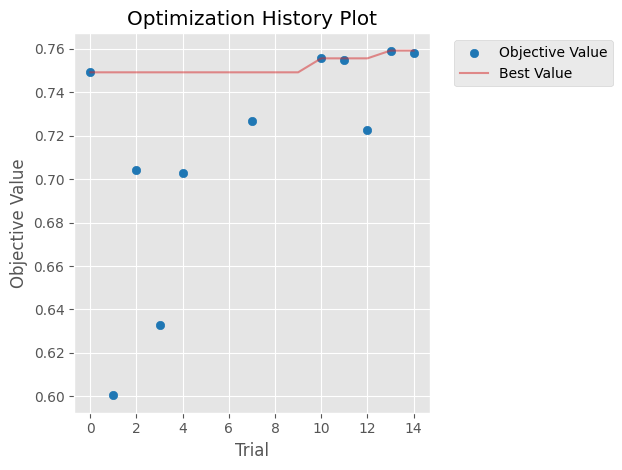

C:\Users\thori\AppData\Local\Temp\ipykernel_2564\1053936043.py:5: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ovm.plot_param_importances(study); plt.tight_layout(); plt.show()


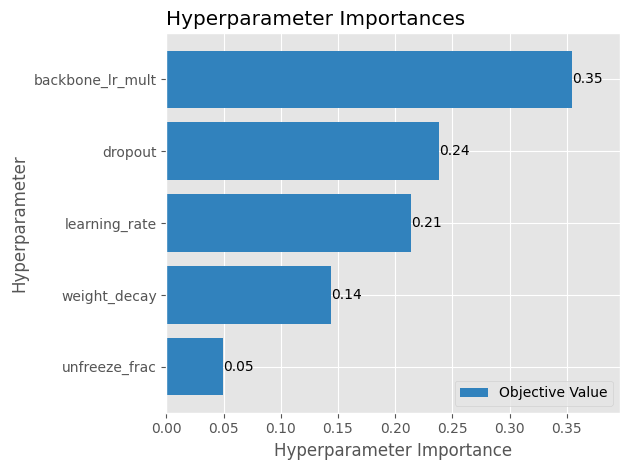

 number    value  params_learning_rate  params_backbone_lr_mult  params_weight_decay  params_dropout  params_unfreeze_frac
     13 0.759209              0.000258                 0.184270             0.000985        0.201726              0.440635
     14 0.758251              0.000301                 0.184061             0.000985        0.283546              0.451545
     10 0.755633              0.000237                 0.402824             0.000247        0.207185              0.156915
     11 0.755074              0.000236                 0.474024             0.000266        0.234234              0.151682
      0 0.749199              0.000237                 0.426650             0.000291        0.439463              0.220208
      7 0.726888              0.000643                 0.053317             0.000016        0.473693              0.348069
     12 0.722696              0.000237                 0.242906             0.000225        0.213496              0.157396
      2 0.704076

In [8]:
if RUN_TUNING:
    try:
        import optuna.visualization.matplotlib as ovm
        ovm.plot_optimization_history(study); plt.tight_layout(); plt.show()
        ovm.plot_param_importances(study); plt.tight_layout(); plt.show()
    except Exception as e:
        print("plot Optuna dilewati:", e)

    top = (study.trials_dataframe()
           .query("state == 'COMPLETE'")
           .sort_values("value", ascending=False)
           [["number", "value", "params_learning_rate", "params_backbone_lr_mult",
             "params_weight_decay", "params_dropout", "params_unfreeze_frac"]])
    print(top.head(10).to_string(index=False))

## 4. Model

In [9]:
model = build_model(cfg, num_classes=num_classes).to(device)
n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_all = sum(p.numel() for p in model.parameters())
_uf = (f"unfreeze_last_n_blocks={cfg['model']['unfreeze_last_n_blocks']}"
       if model.arch.startswith("resnet")
       else f"unfreeze_frac={cfg['model'].get('unfreeze_frac', 0.3)}")
print(f"{model.arch} | emb_dim {model.embedding_dim} | "
      f"trainable {n_tr/1e6:.2f}M / {n_all/1e6:.2f}M  ({cfg['model']['train_mode']}, {_uf})")
if RUN_TUNING:
    print("(hyperparameter dari hasil tuning di atas)")

convnext_small | emb_dim 768 | trainable 31.11M / 49.46M  (finetune_partial, unfreeze_frac=0.4406353983164585)
(hyperparameter dari hasil tuning di atas)


## 5. Training

Loop pakai fungsi dari `src.train`. Tiap epoch dicatat: loss, **MSE (Brier)**,
accuracy, macro-F1 (train & val), learning rate. Loss tiap batch -> `step_losses`.

**EMA** (exponential moving average) bobot di-update tiap epoch -> checkpoint
lebih stabil saat val macro-F1 plateau/berisik. Di akhir: dipilih yang terbaik
antara `best.pth` (per-epoch) vs EMA, di val.

> Loop ini SENGAJA ditulis inline (bukan panggil `src.train.main`) supaya
> terlihat & bisa dimodifikasi. Konsekuensi: sedikit duplikasi dengan
> `src/train.py:main()` — kalau ubah salah satu, samakan yang lain.

In [10]:
class EMA:
    # rata-rata bergerak eksponensial dari state_dict model
    def __init__(self, model, decay=0.8):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            s = self.shadow[k]
            if v.dtype.is_floating_point:
                s.mul_(self.decay).add_(v.detach(), alpha=1 - self.decay)
            else:
                s.copy_(v)

    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)


criterion = nn.CrossEntropyLoss(label_smoothing=cfg["train"]["label_smoothing"])
optimizer = build_optimizer(cfg, model)
scheduler = build_scheduler(cfg, optimizer)
scaler    = make_scaler(device.type, use_amp)
ema       = EMA(model, decay=0.8)

monitor     = cfg["checkpoint"]["monitor"]
monitor_key = monitor.removeprefix("val_")
grad_clip   = cfg["train"].get("grad_clip_norm") or None
patience    = cfg["train"]["early_stopping_patience"]
ckpt_dir    = resolve_path(cfg["checkpoint"]["dir"])

history = {k: [] for k in ["train_loss", "val_loss", "train_mse", "val_mse",
                           "train_accuracy", "val_accuracy",
                           "train_macro_f1", "val_macro_f1", "lr"]}
step_losses = []
best, no_improve = -math.inf, 0
t0 = time.time()

for epoch in range(1, cfg["train"]["epochs"] + 1):
    tr = train_one_epoch(model, loaders["train"], criterion, optimizer, device,
                         scaler, grad_clip, step_losses=step_losses)
    ema.update(model)
    va = validate(model, loaders["val"], criterion, device)
    lr_now = optimizer.param_groups[0]["lr"]
    if scheduler is not None:
        scheduler.step()

    for k in ("loss", "mse", "accuracy", "macro_f1"):
        history[f"train_{k}"].append(tr[k]); history[f"val_{k}"].append(va[k])
    history["lr"].append(lr_now)

    print(f"epoch {epoch:2d}/{cfg['train']['epochs']} | lr {lr_now:.1e} | "
          f"train loss {tr['loss']:.3f} mse {tr['mse']:.3f} f1 {tr['macro_f1']:.3f} | "
          f"val loss {va['loss']:.3f} mse {va['mse']:.3f} f1 {va['macro_f1']:.3f} "
          f"acc {va['accuracy']:.3f}")

    if va[monitor_key] > best:
        best, no_improve = va[monitor_key], 0
        save_checkpoint(model, ckpt_dir / "best.pth", epoch=epoch, monitor=monitor,
                        monitor_value=best, val_metrics=va,
                        label_to_idx=label_to_idx, config=cfg)
        print(f"   -> best {monitor} = {best:.4f}  (checkpoints/best.pth)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping — {monitor} tidak membaik {patience} epoch."); break

save_checkpoint(model, ckpt_dir / "last.pth", epoch=epoch, val_metrics=va,
                label_to_idx=label_to_idx, config=cfg)

# --- pilih model final: best.pth vs EMA (di val) ---
ema_model = build_model(cfg, num_classes=num_classes).to(device)
ema.copy_to(ema_model)
ema_va = validate(ema_model, loaders["val"], criterion, device)
best_va = load_checkpoint(build_model(cfg, num_classes).to(device),
                          ckpt_dir / "best.pth", map_location=str(device))["val_metrics"]
print(f"\nval macro-F1  best.pth {best_va['macro_f1']:.4f}  vs  EMA {ema_va['macro_f1']:.4f}")
if ema_va["macro_f1"] > best_va["macro_f1"]:
    save_checkpoint(ema_model, ckpt_dir / "best.pth", epoch=epoch, monitor=monitor,
                    monitor_value=ema_va["macro_f1"], val_metrics=ema_va,
                    label_to_idx=label_to_idx, config=cfg, note="EMA")
    print("   -> EMA menang, best.pth di-update ke bobot EMA")

# flag overfitting
gap = history["train_macro_f1"][-1] - history["val_macro_f1"][-1]
if gap > 0.15:
    print(f"\n[!] OVERFIT: gap train-val macro-F1 = {gap:.2f} (train {history['train_macro_f1'][-1]:.2f} "
          f"vs val {history['val_macro_f1'][-1]:.2f}). Lever utama: tambah data.")

resolve_path(cfg["output"]["history_json_path"]).write_text(
    json.dumps({**history, "step_losses": step_losses}, indent=2), encoding="utf-8")
print(f"\ntotal {(time.time()-t0)/60:.1f} menit")

epoch  1/40 | lr 2.6e-04 | train loss 1.743 mse 0.673 f1 0.486 | val loss 1.375 mse 0.505 f1 0.600 acc 0.639
   -> best val_macro_f1 = 0.6003  (checkpoints/best.pth)


epoch  2/40 | lr 2.6e-04 | train loss 1.212 mse 0.415 f1 0.718 | val loss 1.216 mse 0.397 f1 0.719 acc 0.735
   -> best val_macro_f1 = 0.7195  (checkpoints/best.pth)


epoch  3/40 | lr 2.6e-04 | train loss 1.040 mse 0.313 f1 0.807 | val loss 1.178 mse 0.369 f1 0.714 acc 0.733


epoch  4/40 | lr 2.5e-04 | train loss 0.917 mse 0.238 f1 0.852 | val loss 1.151 mse 0.343 f1 0.742 acc 0.764
   -> best val_macro_f1 = 0.7416  (checkpoints/best.pth)


epoch  5/40 | lr 2.5e-04 | train loss 0.865 mse 0.205 f1 0.880 | val loss 1.128 mse 0.326 f1 0.736 acc 0.765


...

epoch 27/40 | lr 7.1e-05 | train loss 0.577 mse 0.037 f1 0.988 | val loss 1.054 mse 0.291 f1 0.765 acc 0.794


epoch 28/40 | lr 6.2e-05 | train loss 0.580 mse 0.040 f1 0.987 | val loss 1.066 mse 0.294 f1 0.762 acc 0.793


epoch 29/40 | lr 5.3e-05 | train loss 0.579 mse 0.039 f1 0.988 | val loss 1.058 mse 0.293 f1 0.757 acc 0.792


epoch 30/40 | lr 4.5e-05 | train loss 0.580 mse 0.039 f1 0.989 | val loss 1.050 mse 0.289 f1 0.761 acc 0.789
Early stopping — val_macro_f1 tidak membaik 6 epoch.



val macro-F1  best.pth 0.7790  vs  EMA 0.7697

[!] OVERFIT: gap train-val macro-F1 = 0.23 (train 0.99 vs val 0.76). Lever utama: tambah data.

total 33.4 menit


## 6. Visualisasi Training

### 6a. Loss per step — bukti gradient descent

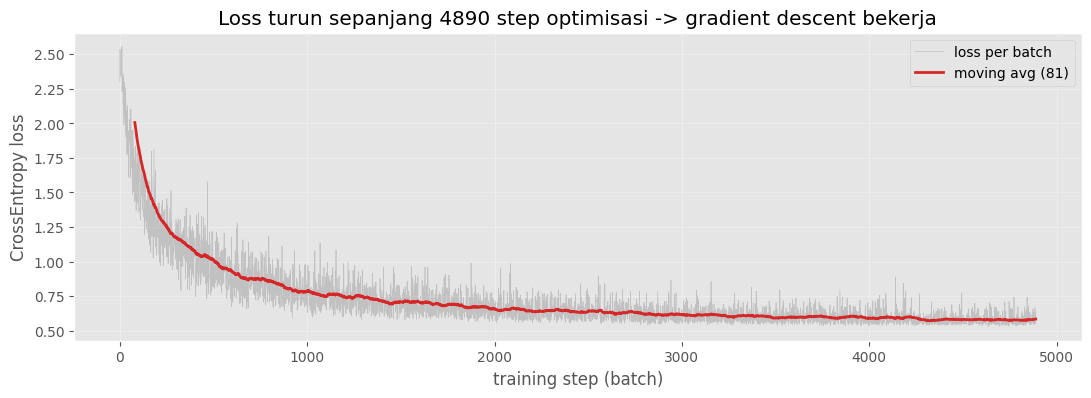

loss step 1 : 2.300  ->  step 4890 : 0.576  (turun 1.724)


In [11]:
plt.figure(figsize=(13, 4))
plt.plot(step_losses, lw=0.5, alpha=0.35, color="gray", label="loss per batch")
k = max(1, len(step_losses) // 60)
if len(step_losses) > k:
    ma = np.convolve(step_losses, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(step_losses)), ma, lw=2, color="tab:red", label=f"moving avg ({k})")
plt.xlabel("training step (batch)"); plt.ylabel("CrossEntropy loss")
plt.title(f"Loss turun sepanjang {len(step_losses)} step optimisasi -> gradient descent bekerja")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(resolve_path("outputs/train_step_loss.png"), dpi=110); plt.show()
print(f"loss step 1 : {step_losses[0]:.3f}  ->  step {len(step_losses)} : {step_losses[-1]:.3f}"
      f"  (turun {step_losses[0]-step_losses[-1]:.3f})")

### 6b. Learning curve — train vs val (loss, MSE/Brier, macro-F1)

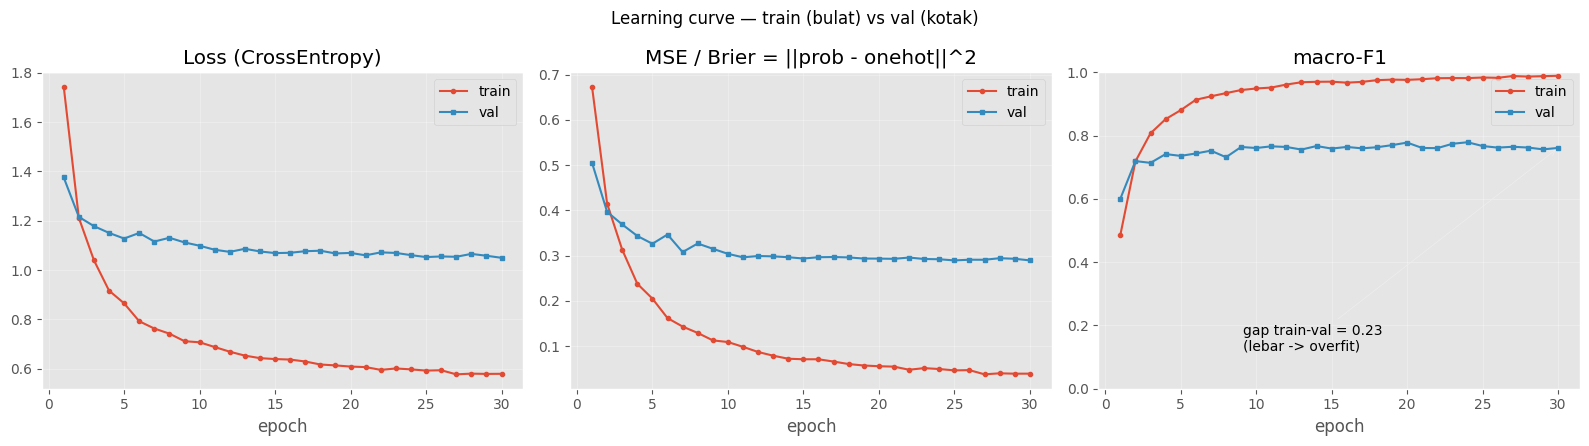

In [12]:
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(ep, history["train_loss"], "o-", ms=3, label="train")
ax[0].plot(ep, history["val_loss"],  "s-", ms=3, label="val")
ax[0].set_title("Loss (CrossEntropy)"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, history["train_mse"], "o-", ms=3, label="train")
ax[1].plot(ep, history["val_mse"],  "s-", ms=3, label="val")
ax[1].set_title("MSE / Brier = ||prob - onehot||^2"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
ax[2].plot(ep, history["train_macro_f1"], "o-", ms=3, label="train")
ax[2].plot(ep, history["val_macro_f1"],  "s-", ms=3, label="val")
ax[2].set_title("macro-F1"); ax[2].set_xlabel("epoch"); ax[2].set_ylim(0, 1); ax[2].legend(); ax[2].grid(alpha=0.3)
gap = history["train_macro_f1"][-1] - history["val_macro_f1"][-1]
ax[2].annotate(f"gap train-val = {gap:.2f}\n(lebar -> overfit)",
               xy=(list(ep)[-1], history["val_macro_f1"][-1]),
               xytext=(0.3, 0.12), textcoords="axes fraction", arrowprops=dict(arrowstyle="->"))
fig.suptitle("Learning curve — train (bulat) vs val (kotak)", fontsize=12)
plt.tight_layout(); plt.savefig(resolve_path("outputs/train_learning_curve.png"), dpi=110); plt.show()

### 6c. Jadwal learning rate

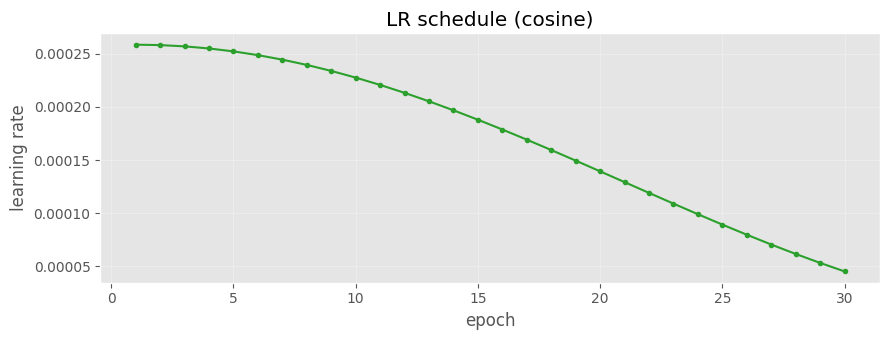

In [13]:
ep = range(1, len(history["lr"]) + 1)
plt.figure(figsize=(9, 3.5))
plt.plot(ep, history["lr"], "o-", ms=3, color="tab:green")
plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.title(f"LR schedule ({cfg['train']['scheduler']})")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(resolve_path("outputs/train_lr_schedule.png"), dpi=110); plt.show()

## 7. Evaluasi Test Set (checkpoint terpilih)

In [14]:
best_model = build_model(cfg, num_classes=num_classes).to(device)
ck = load_checkpoint(best_model, ckpt_dir / "best.pth", map_location=str(device))
print(f"best.pth: epoch {ck.get('epoch')} | {ck.get('monitor')} = {ck.get('monitor_value'):.4f}"
      f" | {ck.get('note', 'per-epoch')}")

# perbandingan best vs last di test (FYI)
last_model = build_model(cfg, num_classes=num_classes).to(device)
load_checkpoint(last_model, ckpt_dir / "last.pth", map_location=str(device))
ev = cfg.get("eval", {})
for tag, mdl in [("best", best_model), ("last", last_model)]:
    yt, yp, _ = run_inference(mdl, loaders["test"], device, tta=ev.get("tta", False))
    from sklearn.metrics import f1_score, accuracy_score
    print(f"  {tag:4s}: test acc {accuracy_score(yt, yp):.3f} | macro-F1 {f1_score(yt, yp, average='macro'):.3f}")

best.pth: epoch 24 | val_macro_f1 = 0.7790 | per-epoch
  best: test acc 0.795 | macro-F1 0.781
  last: test acc 0.795 | macro-F1 0.779


In [15]:
y_true, y_pred, y_prob = run_inference(best_model, loaders["test"], device, tta=ev.get("tta", False))
metrics = compute_metrics(y_true, y_pred, y_prob, idx_to_label,
                          subset_min_support=ev.get("subset_min_support", 8))

print(f"TEST (n={metrics['n_test']}, tta={ev.get('tta', False)})")
for k, lab in [("accuracy", "accuracy      "), ("top3_accuracy", "top-3 accuracy"),
               ("macro_f1", "macro-F1      "), ("weighted_f1", "weighted-F1   "),
               ("mse", "MSE / Brier   ")]:
    print(f"  {lab}: {metrics[k]:.3f}")

print("\nkonteks:")
print("  - baseline (1.132 gambar, 12 kelas)   : test macro-F1 ~0.44")
print("  - literatur WikiArt style (data penuh): ~0.55-0.65 accuracy")
print(f"  - sekarang (5.6k gambar, {num_classes} kelas, tuning={RUN_TUNING}): test macro-F1 {metrics['macro_f1']:.2f}")
print("  - CATATAN: subset 5/72 shard, split TIDAK artist-disjoint, sebagian style")
print("    ter-confound dgn pelukis (Symbolism~Roerich). Jangan overclaim.")

metrics["checkpoint"] = {"epoch": ck.get("epoch"), "monitor_value": ck.get("monitor_value"),
                         "note": ck.get("note", "per-epoch")}
metrics["tuning"] = {"ran": RUN_TUNING, "best_params": (study.best_params if RUN_TUNING else None)}
resolve_path(cfg["output"]["metrics_report_path"]).write_text(
    json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

TEST (n=840, tta=True)
  accuracy      : 0.795
  top-3 accuracy: 0.942
  macro-F1      : 0.781
  weighted-F1   : 0.792
  MSE / Brier   : 0.293

konteks:
  - baseline (1.132 gambar, 12 kelas)   : test macro-F1 ~0.44
  - literatur WikiArt style (data penuh): ~0.55-0.65 accuracy
  - sekarang (5.6k gambar, 11 kelas, tuning=True): test macro-F1 0.78
  - CATATAN: subset 5/72 shard, split TIDAK artist-disjoint, sebagian style
    ter-confound dgn pelukis (Symbolism~Roerich). Jangan overclaim.


3012

### 7a. F1 per kelas

                       precision  recall  f1-score  support
Expressionism              0.520   0.382     0.441     34.0
Post_Impressionism         0.676   0.565     0.615     85.0
Realism                    0.708   0.756     0.731    160.0
Naive_Art_Primitivism      0.767   0.719     0.742     32.0
Cubism                     0.889   0.800     0.842     20.0
Baroque                    0.756   0.971     0.850     35.0
Impressionism              0.832   0.876     0.853    249.0
Symbolism                  0.897   0.825     0.860     63.0
Northern_Renaissance       0.889   0.842     0.865     38.0
Art_Nouveau                0.855   0.883     0.869     60.0
Romanticism                0.935   0.906     0.921     64.0


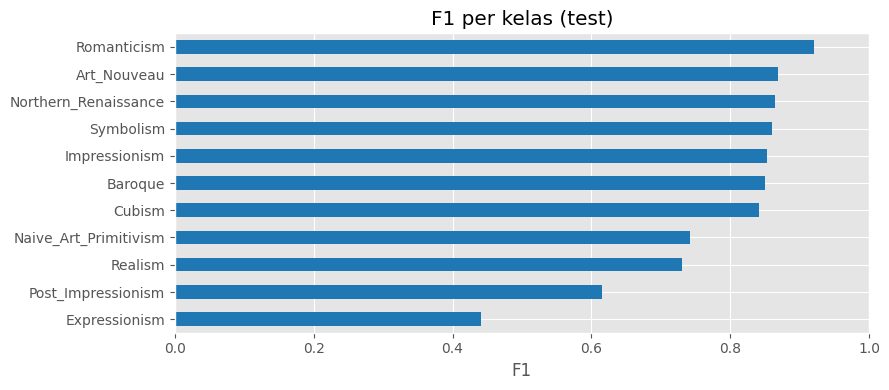

In [16]:
rep = metrics["per_class"]
df = (pd.DataFrame({k: rep[k] for k in class_names}).T
        [["precision", "recall", "f1-score", "support"]].round(3).sort_values("f1-score"))
print(df)
ax = df["f1-score"].plot(kind="barh", figsize=(9, 4), color="tab:blue")
ax.set_xlim(0, 1); ax.set_xlabel("F1"); ax.set_title("F1 per kelas (test)")
plt.tight_layout(); plt.show()

### 7b. Confusion matrix (ternormalisasi per baris)

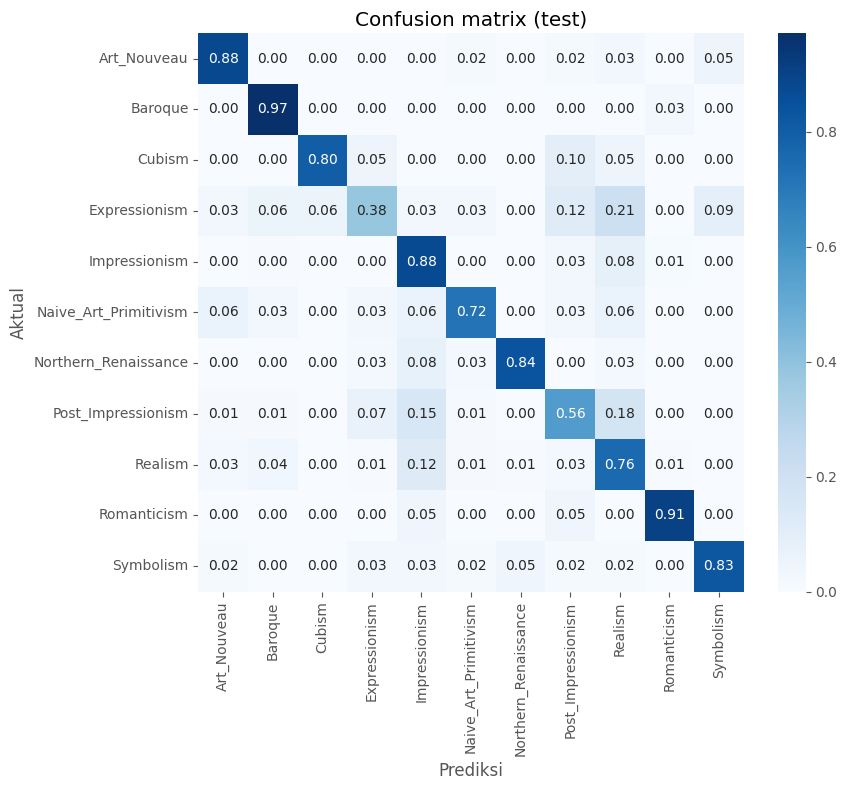

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(9, 8))
try:
    import seaborn as sns
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=True)
except ImportError:
    im = ax.imshow(cm_norm, cmap="Blues")
    ax.set_xticks(range(num_classes), class_names, rotation=90)
    ax.set_yticks(range(num_classes), class_names); fig.colorbar(im, ax=ax)
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual"); ax.set_title("Confusion matrix (test)")
plt.tight_layout(); plt.savefig(resolve_path(cfg["output"]["confusion_matrix_path"]), dpi=110); plt.show()

### 7c. Contoh prediksi acak (hijau = benar, merah = salah)

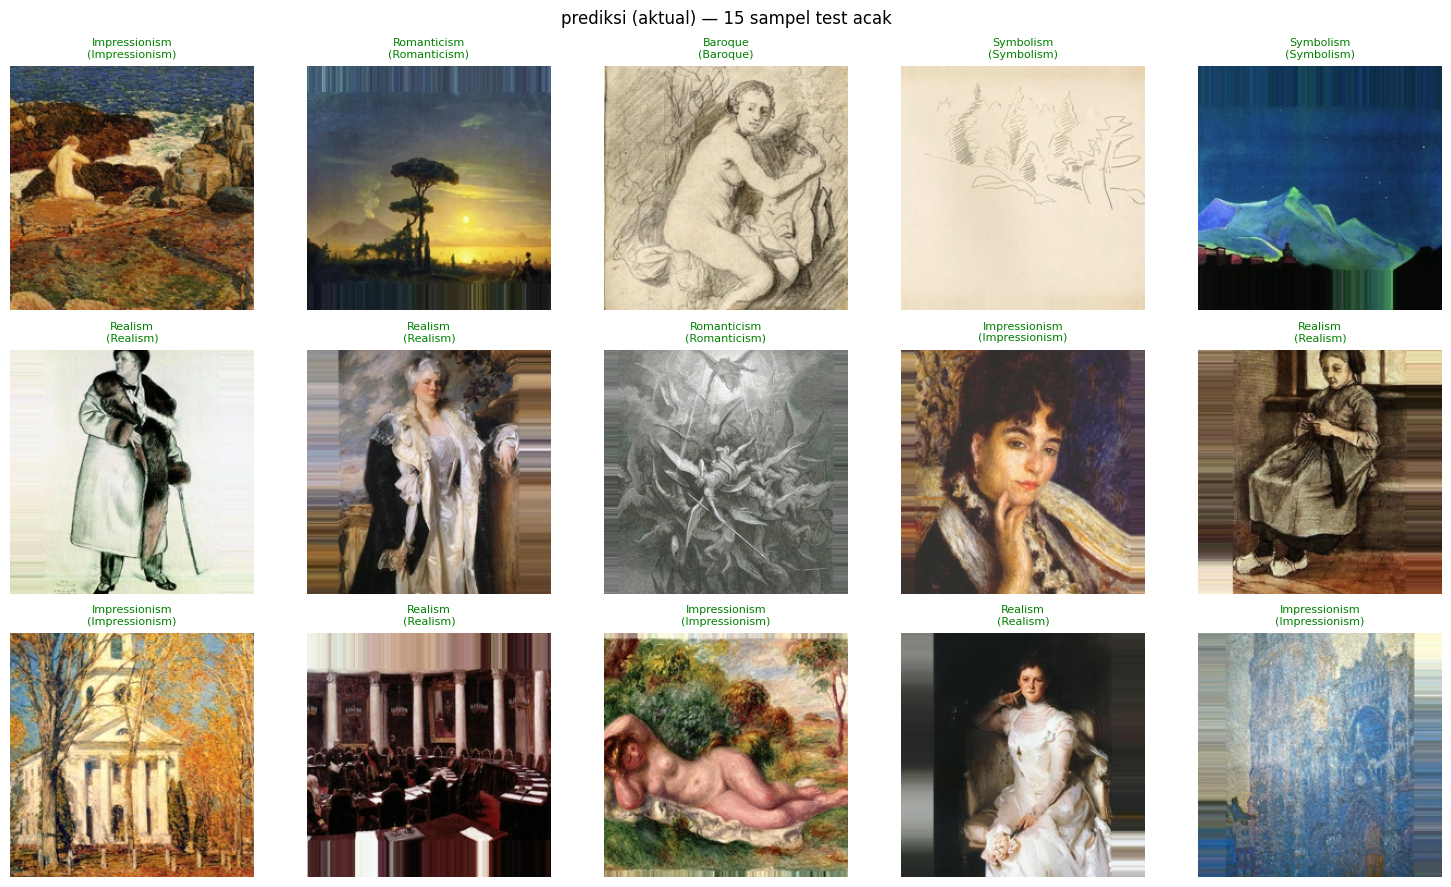

In [18]:
# ambil 15 indeks ACAK dari test set (bukan batch pertama yg bias shard-0)
test_ds = loaders["test"].dataset
rng = np.random.default_rng(cfg["seed"])
pick = rng.choice(len(test_ds), size=15, replace=False)
xs = torch.stack([test_ds[i][0] for i in pick])
ys = [test_ds[i][1] for i in pick]
with torch.no_grad():
    pr = torch.softmax(best_model(xs.to(device)), dim=1).argmax(1).cpu().tolist()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for ax, xi, t, p in zip(axes.flat, xs, ys, pr):
    ax.imshow(denorm(xi)); ax.axis("off")
    ax.set_title(f"{idx_to_label[p]}\n({idx_to_label[t]})", fontsize=8,
                 color="green" if t == p else "red")
fig.suptitle("prediksi (aktual) — 15 sampel test acak"); plt.tight_layout(); plt.show()

## 8. Catatan interpretasi (untuk laporan)

- **Pretext task** = klasifikasi style. Tujuan akhir = embedding untuk Visual
  Search; ukur retrieval@k terpisah (`src/embedding.py`).
- **Hyperparameter tuning**: `learning_rate`, `backbone_lr_mult`, `weight_decay`,
  `dropout`, `unfreeze_frac` dicari otomatis via Optuna (TPE + median pruning),
  bukan tebakan manual — hasil di `outputs/tune_trials.csv` /
  `tune_best_params.json`, bisa dilampirkan ke laporan sbg bukti metodologi.
- **Overfitting**: gap train-val macro-F1 lebar -> model masih menghafal. Obat
  utama = **tambah data** (shard WikiArt). EMA + patience 6 + tuning mengurangi
  noise, bukan menghilangkan overfit sepenuhnya.
- **F1 per kelas** jangan dibaca polos: kelas yang di data ini didominasi 1
  pelukis (Symbolism~Roerich, Northern_Renaissance~Durer) -> F1 tinggi bisa
  berarti pengenalan pelukis, bukan aliran.
- **Model**: `convnext_small` dipilih di atas base/large karena dataset 5.6k
  terlalu kecil untuk kapasitas ekstra (model besar overfit + VRAM 4 GB +
  embedding lebih gemuk untuk Visual Search).
- Keterbatasan: subset shard 0-4 dari 72, tidak representatif, split tidak
  artist-disjoint. Sebut di semua klaim performa.
- Artefak: `outputs/tune_trials.csv`, `tune_best_params.json`,
  `train_step_loss.png`, `train_learning_curve.png`, `train_lr_schedule.png`,
  `confusion_matrix.png`, `metrics_report.json`, `history.json`.